<a href="https://colab.research.google.com/github/Devii16/quiztopia/blob/main/cvlab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
original=cv2.imread('/content/spidy.jpg')
if original is None:
    raise FileNotFoundError("Error: The image at '/content/st.jpg' could not be loaded. Please check the path and ensure the file exists.")
original=cv2.cvtColor(original,cv2.COLOR_BGR2GRAY)

In [ ]:

sobel_x = cv2.Sobel(original, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(original, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.hypot(sobel_x, sobel_y)
sobel = np.uint8(255 * sobel / np.max(sobel))

In [6]:

kernel_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
kernel_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)
prewitt_x = cv2.filter2D(original, cv2.CV_64F, kernel_x)
prewitt_y = cv2.filter2D(original, cv2.CV_64F, kernel_y)
prewitt = np.hypot(prewitt_x, prewitt_y)


max_prewitt = np.max(prewitt)
if max_prewitt > 0:
    prewitt = np.uint8(255 * prewitt / max_prewitt)
else:
    prewitt = np.zeros_like(original, dtype=np.uint8)

In [7]:

canny = cv2.Canny(original, 100, 200)

In [8]:

def show_comparision(original,sobel,prewitt,canny):
  plt.subplot(2,2,1)
  plt.imshow(original,cmap='gray')
  plt.title("original grayscale image")
  plt.axis('off')

  plt.subplot(2,2,2)
  plt.imshow(sobel,cmap='gray')
  plt.title("sobel edge detection")
  plt.axis('off')

  plt.subplot(2,2,3)
  plt.imshow(prewitt,cmap='gray')
  plt.title("prewitt edge detection")
  plt.axis('off')

  plt.subplot(2,2,4)
  plt.imshow(canny,cmap='gray')
  plt.title("canny edge detection")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

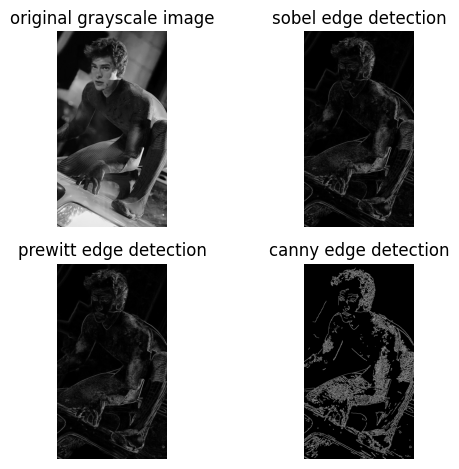

In [10]:
sobel_x = cv2.Sobel(original, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(original, cv2.CV_64F, 0, 1, ksize=3)
sobel = np.hypot(sobel_x, sobel_y)
sobel = np.uint8(255 * sobel / np.max(sobel))
show_comparision(original, sobel, prewitt, canny)